In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
ret=pd.read_csv('Preprocessed data/returns.csv')
ret['Date']=pd.to_datetime(ret['Date'])
ret.head()

,Date,AAPL,AES,AMGN,BEP,COIN,COP,CVS,CVX,CWEN,...,NVDA,Nasdaq_crypto,PFE,PLUG,RIOT,RTX,SP500_ESG,TSLA,UNH,XOM
0,2022-12-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-12-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2022-12-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022-12-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2022-12-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
polls=pd.read_csv('Preprocessed data/polls_smooth.csv')
polls['Date']=pd.to_datetime(polls['Date'])
polls.head()

,Date,TrumpLead,IsHarris
0,2021-09-01,5.966441,0
1,2021-09-02,5.966441,0
2,2021-09-03,5.966441,0
3,2021-09-04,5.966441,0
4,2021-09-05,5.966441,0


In [4]:
fac=pd.read_csv('Preprocessed data/ff_factors.csv')
fac['Date']=pd.to_datetime(fac['Date'])
fac.head()

,Date,Mkt_RF,SMB,HML,RF
0,1926-07-01,0.09,-0.25,-0.27,0.01
1,1926-07-02,0.45,-0.33,-0.06,0.01
2,1926-07-06,0.17,0.30,-0.39,0.01
3,1926-07-07,0.09,-0.58,0.02,0.01
4,1926-07-08,0.22,-0.38,0.19,0.01


In [5]:
df=pd.merge(ret,polls,on='Date',how='left')
df=pd.merge(df,fac,on='Date',how='left')
df[df.columns[1:-6]]=df[df.columns[1:-6]].subtract(df['RF'],axis=0) # Subtract RF from returns
df=df[df['AAPL'].notna()]
df=df.reset_index(drop=True)
df['TrumpLead']=df['TrumpLead'].ffill()
df=df.drop('IsHarris',axis=1)
df.head()

,Date,AAPL,AES,AMGN,BEP,COIN,COP,CVS,CVX,CWEN,...,RTX,SP500_ESG,TSLA,UNH,XOM,TrumpLead,Mkt_RF,SMB,HML,RF
0,2023-08-01,-0.453619,-2.928273,-0.890746,-3.979294,-4.648342,-0.309239,-1.015703,-0.854463,-2.318071,...,0.025480,-0.381300,-2.426928,-0.342418,-0.599820,-1.173712,-0.34,-0.17,0.31,0.02
1,2023-08-02,-1.576011,0.122687,-0.759415,-4.421188,-4.051318,-1.556709,3.252439,-1.616158,-2.134409,...,-2.914742,-1.493387,-2.722133,-0.008113,-1.275266,-1.173712,-1.49,-0.18,0.57,0.02
2,2023-08-03,-0.754857,-1.891007,0.105783,-1.248301,0.333240,-0.540428,-2.793348,-0.057570,-2.422999,...,-0.948708,-0.302765,2.009558,-0.008115,1.703125,-1.173712,-0.19,-0.04,0.08,0.02
3,2023-08-04,-4.941134,-5.034702,5.289488,1.243175,-3.884347,-1.139382,-1.962864,-0.245720,1.028397,...,-0.161827,-0.509846,-2.147989,-0.442792,0.259668,-1.173712,-0.48,0.03,0.76,0.02
4,2023-08-07,-1.760427,0.285033,3.873926,0.432253,-1.578293,0.654879,1.369668,0.343409,-0.220763,...,1.062236,0.767603,-0.973877,1.560741,-0.225014,-1.170105,0.77,-1.16,0.60,0.02


In [6]:
# Filter values of the appropriate days
event_day=pd.to_datetime('2024-11-05')
event_day_idx=df.index[df['Date']==event_day][0]
event_window_idx=list(range(event_day_idx-2,event_day_idx+6)) # Event window from t-2 to t+5
puffer_days=30
T=120
estimation_window_idx=list(range(min(event_window_idx)-puffer_days-T,min(event_window_idx)-puffer_days))

In [7]:
# Create linear regression data & model
import statsmodels.api as sm
from scipy import stats

X_estim=sm.add_constant(df.iloc[estimation_window_idx,-5:-1])
Y_estim=df.iloc[estimation_window_idx,1:-5]

ff3_model=sm.OLS(Y_estim,X_estim).fit()

ff3_model.params

,0,1,2,3,4,5,6,7,8,9,...,24,25,26,27,28,29,30,31,32,33
const,0.149683,-0.001596,0.059421,0.107065,-0.651803,-0.116589,-0.313319,-0.100262,0.090772,0.096735,...,-0.044441,-0.314889,0.019284,-0.499445,-0.626974,0.071309,-0.009251,0.137887,0.068156,-0.031416
TrumpLead,0.040086,-0.089857,0.070843,-0.038079,0.338934,-0.125923,0.053760,-0.042655,0.162611,0.068480,...,0.214154,0.142103,0.028724,-0.138918,0.131022,0.204785,0.013488,-0.076831,0.146736,0.004372
Mkt_RF,0.945164,0.922170,0.874910,1.009619,2.547616,0.621130,0.733816,0.795698,0.652181,0.059832,...,2.432756,2.027941,0.334083,1.559752,2.749412,0.332405,1.003971,2.323531,0.215000,0.497805
SMB,-0.051935,0.620665,0.045171,0.433552,0.734469,-0.023228,-0.093451,-0.140419,0.436197,0.119413,...,-0.581567,0.295406,0.228062,2.329777,1.282147,0.125212,-0.104434,-0.048492,0.253158,-0.132942
HML,-0.288546,-0.098782,0.482659,0.015918,-0.310644,0.730238,1.069836,0.935336,0.182203,0.524278,...,-2.073794,0.542821,0.511956,-0.363283,1.174407,0.393129,-0.030577,-0.487790,0.785761,0.866242


In [8]:
X_event=sm.add_constant(df.iloc[event_window_idx,-5:-1])
Y_pred_event=ff3_model.predict(X_event) # Predicted event window returns
Y_event=df.iloc[event_window_idx,1:-5] # Real event window returns

In [9]:
# Calculating abnormal returns
AR_event=pd.DataFrame(
    Y_event.values-Y_pred_event.values,
    index=Y_event.index,
    columns=Y_event.columns
)

AAR_event=AR_event.mean(axis=1)
CAR_event_m2_p5=AR_event.cumsum()
CAAR_event_m2_p5=AAR_event.cumsum()
CAAR_event_m2_p5

317   -1.117388
318   -0.053683
319   -0.035701
320   -1.811892
321   -2.285830
322   -1.367735
323    0.290706
324   -0.916545
dtype: float64

In [10]:
# Stock grouping
stocks_all=pd.read_excel('candidate_stocks.xlsx',sheet_name='stocks')
sectors_all=pd.read_excel('candidate_stocks.xlsx',sheet_name='sectors')

stocks_trump=[s for s in stocks_all['Trump'] if pd.notna(s)]
stocks_harris=[s for s in stocks_all['Harris'] if pd.notna(s)]
stocks_tech=[s for s in stocks_all['Tech'] if pd.notna(s)]

sectors_trump=[s for s in sectors_all['Trump'] if pd.notna(s)]
sectors_harris=[s for s in sectors_all['Harris'] if pd.notna(s)]

In [11]:
# Average abnormal returns by groups
AAR_stocks_trump=AR_event[stocks_trump].mean(axis=1)
AAR_stocks_harris=AR_event[stocks_harris].mean(axis=1)
AAR_stocks_tech=AR_event[stocks_tech].mean(axis=1)

AAR_sectors_trump=AR_event[sectors_trump].mean(axis=1)
AAR_sectors_harris=AR_event[sectors_harris].mean(axis=1)

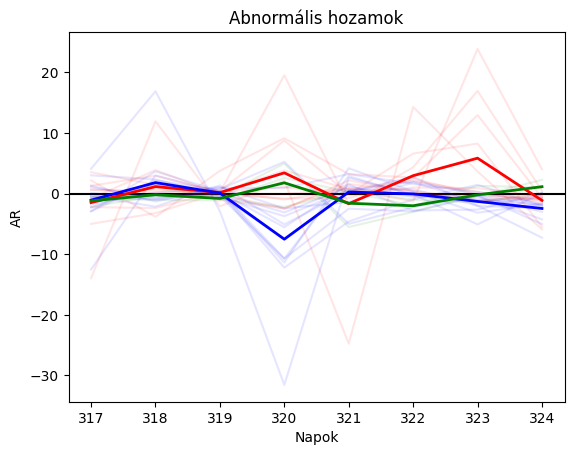

In [12]:
plt.axhline(0,color='black')

for col in AR_event.columns:
    if col in stocks_trump:
        plt.plot(AR_event.index,AR_event[col],color='red',label=col,alpha=0.1)
    elif col in stocks_harris:
        plt.plot(AR_event.index,AR_event[col],color='blue',label=col,alpha=0.1)
    elif col in stocks_tech:
        plt.plot(AR_event.index,AR_event[col],color='green',label=col,alpha=0.1)

plt.plot(AAR_stocks_trump,color='red',label=col,linewidth=2)
plt.plot(AAR_stocks_harris,color='blue',label=col,linewidth=2)
plt.plot(AAR_stocks_tech,color='green',label=col,linewidth=2)

plt.title('Abnormális hozamok')
plt.xlabel('Napok')
plt.ylabel('AR')

plt.savefig('plot.pdf')

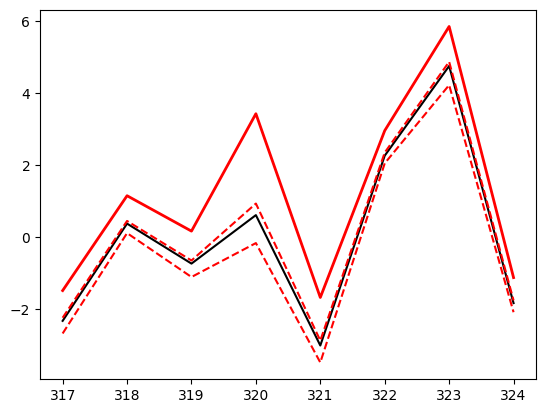

<Figure size 640x480 with 0 Axes>

In [13]:
# Bootstrap for Trump stocks
AAR_boot=list()
M=10000

for i in range(M):
    df_boot=df.loc[estimation_window_idx,:].sample(T,replace=True)
    X_boot=sm.add_constant(df_boot.iloc[:,-5:-1])
    Y_boot=df_boot.loc[:,stocks_trump]
    model_boot=sm.OLS(Y_boot,X_boot).fit()
    Y_pred_boot=model_boot.predict(X_event)
    AR_boot=pd.DataFrame(
        Y_event.loc[:,stocks_trump].values-Y_pred_boot.values,
        index=Y_event.index,
        columns=stocks_trump
    )
    AAR_boot.append(list(AR_boot.mean(axis=1)))

p10=np.percentile(AAR_boot,0.025,axis=0)
med=np.percentile(AAR_boot,0.5,axis=0)
p90=np.percentile(AAR_boot,0.975,axis=0)

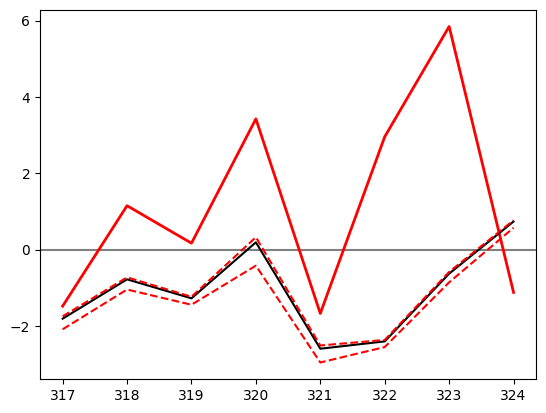

In [27]:
plt.axhline(0,color='gray')
plt.plot(AAR_stocks_trump,color='red',label=col,linewidth=2)
plt.plot(event_window_idx,p10,color='red',label='p10',linestyle='--')
plt.plot(event_window_idx,med,color='black',label='med')
plt.plot(event_window_idx,p90,color='red',label='p90',linestyle='--')

plt.savefig('btstrp_trump.svg')

plt.show()

In [19]:
# Bootstrap for Harris stocks
AAR_boot=list()
M=10000

for i in range(M):
    df_boot=df.loc[estimation_window_idx,:].sample(T,replace=True)
    X_boot=sm.add_constant(df_boot.iloc[:,-5:-1])
    Y_boot=df_boot.loc[:,stocks_harris]
    model_boot=sm.OLS(Y_boot,X_boot).fit()
    Y_pred_boot=model_boot.predict(X_event)
    AR_boot=pd.DataFrame(
        Y_event.loc[:,stocks_harris].values-Y_pred_boot.values,
        index=Y_event.index,
        columns=stocks_harris
    )
    AAR_boot.append(list(AR_boot.mean(axis=1)))

p10=np.percentile(AAR_boot,0.025,axis=0)
med=np.percentile(AAR_boot,0.5,axis=0)
p90=np.percentile(AAR_boot,0.975,axis=0)

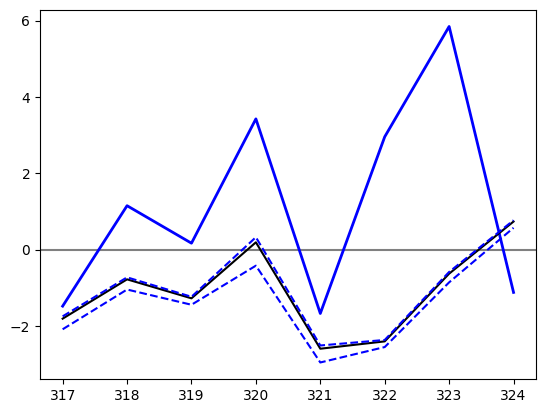

In [26]:
plt.axhline(0,color='gray')
plt.plot(AAR_stocks_trump,color='blue',label=col,linewidth=2)
plt.plot(event_window_idx,p10,color='blue',label='p10',linestyle='--')
plt.plot(event_window_idx,med,color='black',label='med')
plt.plot(event_window_idx,p90,color='blue',label='p90',linestyle='--')

plt.savefig('btstrp_harris.svg')

plt.show()

In [21]:
# Bootstrap for Tech stocks
AAR_boot=list()
M=10000

for i in range(M):
    df_boot=df.loc[estimation_window_idx,:].sample(T,replace=True)
    X_boot=sm.add_constant(df_boot.iloc[:,-5:-1])
    Y_boot=df_boot.loc[:,stocks_tech]
    model_boot=sm.OLS(Y_boot,X_boot).fit()
    Y_pred_boot=model_boot.predict(X_event)
    AR_boot=pd.DataFrame(
        Y_event.loc[:,stocks_tech].values-Y_pred_boot.values,
        index=Y_event.index,
        columns=stocks_tech
    )
    AAR_boot.append(list(AR_boot.mean(axis=1)))

p10=np.percentile(AAR_boot,0.025,axis=0)
med=np.percentile(AAR_boot,0.5,axis=0)
p90=np.percentile(AAR_boot,0.975,axis=0)

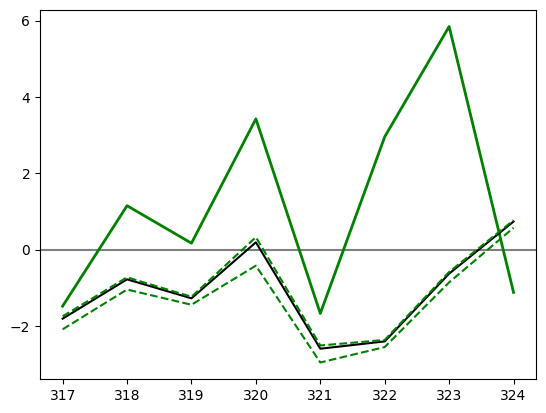

In [25]:
plt.axhline(0,color='gray')
plt.plot(AAR_stocks_trump,color='green',label=col,linewidth=2)
plt.plot(event_window_idx,p10,color='green',label='p10',linestyle='--')
plt.plot(event_window_idx,med,color='black',label='med')
plt.plot(event_window_idx,p90,color='green',label='p90',linestyle='--')

plt.savefig('btstrp_tech.svg')

plt.show()